# Homework 4 solution
- INFO 4871 / 5871
- Spring 2019
- Professor Robin Burke

## Objective (all students)
The object of this assignment is to gain familiarity with content-based recommendation algorithms. You will do this by implementing a simple hybrid recommender system and evaluating it relative to its components. I have provided the following:
- An outline of the NaiveBayesRecommender class. 
- A test case for the NaiveBayesRecommender class

You will first implement the NaiveBayesRecommender. It takes an item-feature table and produces a set of tables counting the user / feature / like (~like) combinations. 

Then you will use the algorithm to generate content-based recommendations for the MovieLens dataset using the "genre" values found in the movie table, and evaluate based on precision @ 10 compared to the item-item recommender.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
from lenskit import batch, topn, util
from lenskit import crossfold as xf
from lenskit.algorithms import Predictor, Recommender
from lenskit.algorithms.item_knn import ItemItem


In [124]:
import math

## Import NaiveBayesRecommender
Use autoimport to support development of the NaiveBayes code

In [3]:
%load_ext autoreload
%aimport naive_bayes
%autoreload 2

from naive_bayes import NaiveBayesRecommender

In [4]:
import unittest
from test_naive_bayes import test_NaiveBayes

%aimport test_naive_bayes

### Running unit tests

In [23]:
suite = unittest.TestLoader().loadTestsFromTestCase(test_naive_bayes.test_NaiveBayes)
runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)

test_cond_prob (test_naive_bayes.test_NaiveBayes) ... ok
test_cond_tables (test_naive_bayes.test_NaiveBayes) ... ok
test_liked_prob (test_naive_bayes.test_NaiveBayes) ... ok
test_liked_tables (test_naive_bayes.test_NaiveBayes) ... ok
test_pred1 (test_naive_bayes.test_NaiveBayes) ... ok
test_pred2 (test_naive_bayes.test_NaiveBayes) ... ok
test_pred3 (test_naive_bayes.test_NaiveBayes) ... ok
test_recommend (test_naive_bayes.test_NaiveBayes) ... ok
test_reset (test_naive_bayes.test_NaiveBayes) ... ok
test_zeros (test_naive_bayes.test_NaiveBayes) ... ok

----------------------------------------------------------------------
Ran 10 tests in 0.301s

OK


<unittest.runner.TextTestResult run=10 errors=0 failures=0>

## Evaluation
Load ratings

In [58]:
ratings = pd.read_csv('ml_ratings.csv', usecols=['userId','movieId','rating'])
ratings = ratings.rename(columns={"userId": "user", "movieId": "item"})
ratings.head()

,user,item,rating
0,12882,1,4.0
1,12882,32,3.5
2,12882,47,5.0
3,12882,50,5.0
4,12882,110,4.5


Load movie information

In [59]:
movies = pd.read_csv('ml_movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


### Genre
Split out genres into a separate data frame with "Item", "Feature" columns.

In [60]:
items = []
genres = []
for i, r in movies.iterrows():
    genres_list = r['genres'].split('|')
    items+=len(genres_list)*[r['movieId']]
    genres+=(genres_list)

data = {'item': items,'feature': features}
features = pd.DataFrame(data, columns=['item', 'feature'])

features.head()

,item,feature
0,1,Adventure
1,1,Animation
2,1,Children
3,1,Comedy
4,1,Fantasy


## Instantiate algorithms
### Naive Bayes
Like / dislike threshold = 2.9
alpha = 0.01
beta = 0.02

In [61]:
naive_bayes = NaiveBayesRecommender(features, 2.9, 0.01, 0.02)

### Item-based knn
neighbors = 20
minimum similarity = 0
center = True
aggregate = weighted-average

In [62]:
item_based = ItemItem(min_sim=0, aggregate='weighted-average', center=True, nnbrs=20)

Supplied: eval_recs

In [63]:
def eval_recs(aname, fold, algo, train, test):
    fittable = util.clone(algo)
    fittable = Recommender.adapt(fittable)
    fittable.fit(train)
    
    users = test.user.unique()
    recs = batch.recommend(fittable, users, 10)
    # add the algorithm
    recs['Algorithm'] = aname
    recs['Fold'] = fold
    return recs

5-fold cross-validation

In [64]:
np.random.seed(20190317)

all_recs1 = []
test_data1 = []
fold = 0
# 5 fold cross-validation
for train, test in xf.partition_users(ratings[['user', 'item', 'rating']], 5, xf.SampleFrac(0.2)):
    test_data1.append(test)
    all_recs1.append(eval_recs('ItemKnn',fold, item_based, train, test))
    all_recs1.append(eval_recs('NaiveBayes',fold, naive_bayes, train, test))
    print("Completed fold {}".format(fold))
    fold += 1

Completed fold 0
Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4


Put answers together

In [67]:
all_recs12 = pd.concat(all_recs1, ignore_index=True)
test_data12 = pd.concat(test_data1, ignore_index=True)
all_recs12.head()

,item,score,user,rank,Algorithm,Fold
0,1303,4.539340,359,1,ItemKnn,0
1,1283,4.522639,359,2,ItemKnn,0
2,1214,4.515755,359,3,ItemKnn,0
3,78499,4.507841,359,4,ItemKnn,0
4,2729,4.498951,359,5,ItemKnn,0


Run evaluation with precision

In [176]:
rla = topn.RecListAnalysis()
rla.add_metric(topn.precision)
rla.add_metric(topn.recall)
results = all_recs12.groupby(['Algorithm', 'Fold']).apply(lambda df: rla.compute(df, test_data12))

In [177]:
results2 = results.groupby(['Algorithm', 'Fold'])
results2 = results2.mean()
results_mean=results2.groupby(['Algorithm']).mean()['precision']
results_std = results2.groupby(['Algorithm']).std()['precision']

In [178]:
results_df = pd.DataFrame({'mean': results_mean,'std': results_std})
results_df

,mean,std
Algorithm,,
ItemKnn,0.117266,0.010401
NaiveBayes,0.040835,0.003098


Plot using a bar chart with error bars as in Homework 3

Text(0,0.5,'precision')

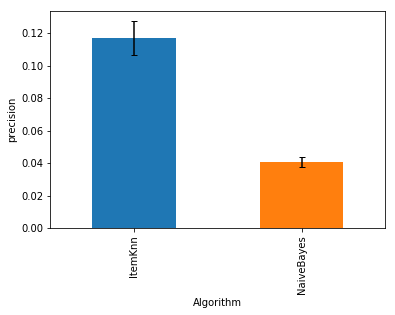

In [113]:
results_mean.plot.bar(yerr=results_std, capsize=3).set_ylabel('precision')

### Question
You can see that the content-based recommender has lower precision@10 than the collaborative one. Do you think that a weighted hybrid of these two methods would be better than the collaborative one alone? Justify your answer.

### Answer
_Your answer here_

## Using tags as content (INFO 5871)
Here you will use the same implementation as above, but you will use a different set of content data -- the tags from `ml_tags.csv`.

In [122]:
tags = pd.read_csv('ml_tags.csv', encoding='latin_1')
tags.head()

,movieId,userId,tag,timestamp
0,3916,12882,sports,1147195545
1,4085,12882,Eddie Murphy,1147195966
2,33660,12882,boxing,1147195514
3,1197,320,must show,1145964801
4,1396,320,must show,1145964810


In [121]:
len(tags)

94875

Calculate entropy of tag collection

$e_{tag} = - p_{tag} \log_{2} p_{tag}$

$p_{tag}$ = count of tag occurence / number of tagging events

In [135]:
ptag = tags['tag'].value_counts()/len(tags)
etag = -ptag * np.log2(ptag)
etag.head()

based on a book    0.056365
atmospheric        0.047244
CLV                0.047183
sci-fi             0.040849
quirky             0.038325
Name: tag, dtype: float64

In [142]:
tags_df = pd.DataFrame({'prob': ptag, 'entropy': etag})
tags_df.head()

,prob,entropy
based on a book,0.008116,0.056365
atmospheric,0.006503,0.047244
CLV,0.006493,0.047183
sci-fi,0.005428,0.040849
quirky,0.005017,0.038325


Drop tags with entropy <= 0.001. (There aren't tags with high entropy, so we won't filter for that.)

In [143]:
tags_df = tags_df[tags_df.entropy > 0.001]
tags_df.head()

,prob,entropy
based on a book,0.008116,0.056365
atmospheric,0.006503,0.047244
CLV,0.006493,0.047183
sci-fi,0.005428,0.040849
quirky,0.005017,0.038325


Use this set of tags to filtering the original tag data so that it only includes the tags with higher entropy.

In [150]:
movieTag_df = tags_df.join(tags.set_index('tag'))
movieTag_df.head()

,prob,entropy,movieId,userId,timestamp
"""damn dirty apes""",0.000116,0.001516,2529,27898,1279147178
"""damn dirty apes""",0.000116,0.001516,2530,10514,1341510171
"""damn dirty apes""",0.000116,0.001516,2530,134156,1181700629
"""damn dirty apes""",0.000116,0.001516,2531,134156,1181700651
"""damn dirty apes""",0.000116,0.001516,2533,134156,1181700658


Convert filtered tag data to collection of features for the content-based recommender

In [167]:
movieTag_df2 = movieTag_df.reset_index().rename(columns={"index": "feature"})
tag_features = pd.DataFrame({'item': movieTag_df2.movieId, 'feature': movieTag_df2.feature})

In [168]:
tag_features.head()

,item,feature
0,2529,"""damn dirty apes"""
1,2530,"""damn dirty apes"""
2,2530,"""damn dirty apes"""
3,2531,"""damn dirty apes"""
4,2533,"""damn dirty apes"""


Create the NaiveBayesRecommender with these features. thresh=2.9, alpha=0.01, beta=0.02

In [169]:
naive_bayes2 = NaiveBayesRecommender(tag_features, 2.9, 0.01, 0.02)

Run the evaluation

In [170]:
np.random.seed(20190317)

all_recs2 = []
test_data2 = []
fold = 0
# Evaluation code here
for train, test in xf.partition_users(ratings[['user', 'item', 'rating']], 5, xf.SampleFrac(0.2)):
    test_data2.append(test)
    all_recs2.append(eval_recs('NaiveBayes',fold, naive_bayes2, train, test))
    print("Completed fold {}".format(fold))
    fold += 1

Completed fold 0
Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4


Assemble the results data

In [172]:
all_recs22 = pd.concat(all_recs2, ignore_index=True)
test_data22 = pd.concat(test_data2, ignore_index=True)
all_recs22.head()

,item,score,user,rank,Algorithm,Fold
0,1089,341.285805,359,1,NaiveBayes,0
1,111,340.944902,359,2,NaiveBayes,0
2,1213,339.365908,359,3,NaiveBayes,0
3,56367,286.164112,359,4,NaiveBayes,0
4,8874,274.980518,359,5,NaiveBayes,0


Compute precision at 10.

In [179]:
results2 = all_recs22.groupby(['Algorithm', 'Fold']).apply(lambda df: rla.compute(df, test_data22))
results22 = results2.groupby(['Algorithm', 'Fold'])
results22 = results22.mean()
results_mean2=results22.groupby(['Algorithm']).mean()['precision']
results_std2 = results22.groupby(['Algorithm']).std()['precision']
results_df2 = pd.DataFrame({'mean': results_mean2,'std': results_std2})
results_df2

,mean,std
Algorithm,,
NaiveBayes,0.218687,0.008183


Combine with the results from part 1

In [180]:
results_df3 = results_df.append(results_df2)
results_df3.index = ['ItemKnn', 'Genre', 'Tags']
results_df3

,mean,std
ItemKnn,0.117266,0.010401
Genre,0.040835,0.003098
Tags,0.218687,0.008183


Plot all three results as a bar plot with error bars.

Text(0,0.5,'precision')

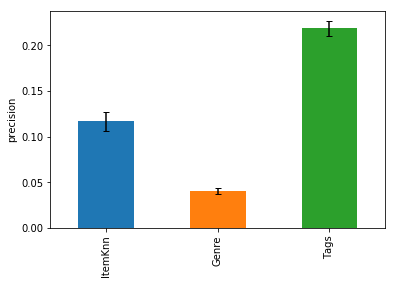

In [183]:
results_df3['mean'].plot.bar(yerr=results_df3['std'], capsize=3).set_ylabel('precision')

### Question
You will see that the tags form a better basis for content-based recommendation than the genre data and even better than the collaborative recommender. Why do you think this is the case here when the genre-based method was not as good? 

### Answer
_your answer here_